In [1]:
# Data visualization notebook that performs histogram and CDF analysis
# for each MASS turbulence layer at 500 m, 1 km, 2 km, 4 km, 8 km,
# and 16 km using the `layer_plot()` function.
#
# For each atmospheric layer, the notebook generates a histogram with
# an overlaid cumulative distribution function (CDF) to examine the
# statistical distribution of logarithmic layer-strength values.
#
# The analysis highlights key statistical properties including minimum,
# maximum, median, mean, standard deviation, and modal bin ranges for
# each layer. Median and modal-bin markers are overlaid on the plots to
# emphasize characteristic turbulence-strength regions within the data.
#
# These visualizations are used to compare turbulence distributions
# across atmospheric layers and identify differences in variability,
# spread, and dominant layer-strength behavior.

import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
file = 'path/to/master_file'
hdul = fits.open(file)
data = hdul[1].data 

ground_layer = data['ground_layer']
mass_val = data['mass_val']
dimm_val = data['dimm_val']

half = np.log10(data['500m'])
one = np.log10(data['1km'])
two = np.log10(data['2km'])
four = np.log10(data['4km'])
eight = np.log10(data['8km'])
sixteen = np.log10(data['16km'])

In [5]:
# Load the CSV
df = pd.read_csv("master_file.csv")
df["gl_strength"] = total_profile

percent500 = []
percent1 = []
percent2 = []
percent4 = []
percent8 = []
percent16 = []
percentGL = []

for i in range(len(df)):
    total = df['500m'][i] + df['1km'][i] + df['2km'][i] + df['4km'][i] + df['8km'][i] + df['16km'][i] + df['gl_strength'][i]
    a1 = round( ( df['500m'][i] / total ) * 100 , 0 )
    a2 = round( ( df['1km'][i] / total ) * 100 , 0 )
    a3 = round( ( df['2km'][i] / total ) * 100 , 0 )
    a4 = round( ( df['4km'][i] / total ) * 100 , 0 )
    a5 = round( ( df['8km'][i] / total ) * 100 , 0 )
    a6 = round( ( df['16km'][i] / total ) * 100 , 0 )
    a7 = round( ( df['gl_strength'][i] / total ) * 100 , 0 )

    percent500.append(a1)
    percent1.append(a2)
    percent2.append(a3)
    percent4.append(a4)
    percent8.append(a5)
    percent16.append(a6)
    percentGL.append(a7)

df["percent500m"] = percent500
df["percent1km"] = percent1
df["percent2km"] = percent2
df["percent4km"] = percent4
df["percent8km"] = percent8
df["percent16km"] = percent16
df["percentGL"] = percentGL

print(df)

                   datetime          500m           1km           2km  \
0       2020-01-21 22:06:37  1.550000e-22  1.140000e-16  1.610000e-16   
1       2020-01-21 22:08:08  5.500000e-22  1.890000e-22  1.140000e-19   
2       2020-01-21 22:11:08  1.140000e-22  6.410000e-17  1.310000e-16   
3       2020-01-22 03:36:39  4.210000e-23  1.040000e-14  3.410000e-15   
4       2020-01-22 04:28:56  9.360000e-15  3.120000e-14  3.320000e-14   
...                     ...           ...           ...           ...   
272968  2011-12-31 02:25:51  6.360000e-22  7.470000e-23  8.810000e-16   
272969  2011-12-31 02:27:23  7.210000e-23  1.180000e-24  1.840000e-21   
272970  2011-12-31 02:39:43  2.000000e-21  4.480000e-23  5.920000e-21   
272971  2011-12-31 02:45:51  4.650000e-23  4.280000e-23  1.100000e-21   
272972  2011-12-31 02:56:34  6.650000e-22  9.480000e-23  6.490000e-20   

                 4km           8km          16km  mass_val  dimm_val  \
0       1.330000e-14  9.300000e-15  1.720000e-14   

In [6]:
print(round(np.mean(df['percent500m']),2))

df.to_csv('revised.csv', index=False)

3.59


In [28]:
def layer_plot(data):
    
    mask = data > -20
    filtered = data[mask]
    
    # --- Create figure with dual y-axis ---
    fig, ax1 = plt.subplots(figsize=(8,6))
    
    # Histogram on left y-axis
    counts, bins, patches = ax1.hist(
        filtered, bins=20, color='skyblue', edgecolor='black', alpha=0.7, label="Histogram"
    )
    index_max_count = np.argmax(counts)
    
    ax1.set_xlabel("Log (Layer Strength)")
    ax1.set_ylabel("Counts per Bin", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    
    # Add vertical line at 50% ground layer
    ax1.axvline(x=np.median(filtered), color="purple", linestyle="--", linewidth=1.5)

    ax1.axvline(x=bins[index_max_count], color="pink", linestyle="--", linewidth=1.5)
    ax1.axvline(x=bins[index_max_count+1], color="pink", linestyle="--", linewidth=1.5)
    
    # CDF on right y-axis
    ax2 = ax1.twinx()
    sorted_vals = np.sort(filtered)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax2.plot(sorted_vals, cdf, color="red", linewidth=2, label="CDF")
    ax2.set_ylabel("CDF", color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    
    # Add horizontal line at 50% CDF
    ax2.axhline(y=0.5, color="green", linestyle="--", linewidth=1.5)
    
    # Title and grid
    if (data == half).all():
        ax1.set_title("Layer = 500m // Histogram and CDF")
    if (data == one).all():
        ax1.set_title("Layer = 1km // Histogram and CDF")
    if (data == two).all():
        ax1.set_title("Layer = 2km // Histogram and CDF")
    if (data == four).all():
        ax1.set_title("Layer = 4km // Histogram and CDF")
    if (data == eight).all():
        ax1.set_title("Layer = 8km // Histogram and CDF")
    if (data == sixteen).all():
        ax1.set_title("Layer = 16km // Histogram and CDF")
        
    ax1.grid(True, axis="y")
    #plt.xlim(0,1.5)
    
    #plt.savefig('wind_dir_hist.png')
    plt.show()
    
    print('Max Value = ', round(np.max(filtered),2))
    print('Min Value = ', round(np.min(filtered),2))
    print('Median Value = ', round(np.median(filtered),2))
    print('Standard Deviation = ', round(np.std(filtered),2))
    print('Average = ', round(np.mean(filtered),2))

    mode = ( bins[index_max_count+1] + bins[index_max_count] ) / 2
    edge = bins[index_max_count+1] - mode

    print('Mode Bin Value = ', round(mode,2), '+/-', round(edge,2))

    return

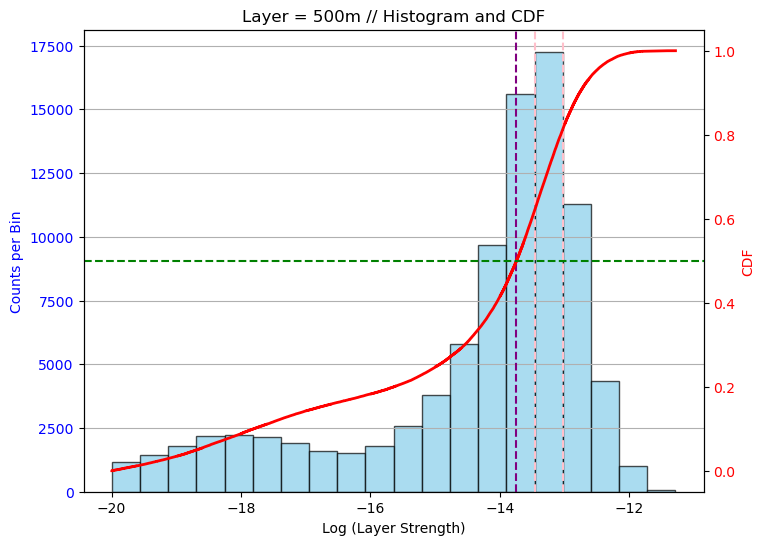

Max Value =  -11.29
Min Value =  -20.0
Median Value =  -13.74
Standard Deviation =  1.88
Average =  -14.43
Mode Bin Value =  -13.25 +/- 0.22


In [29]:
layer_plot(half)

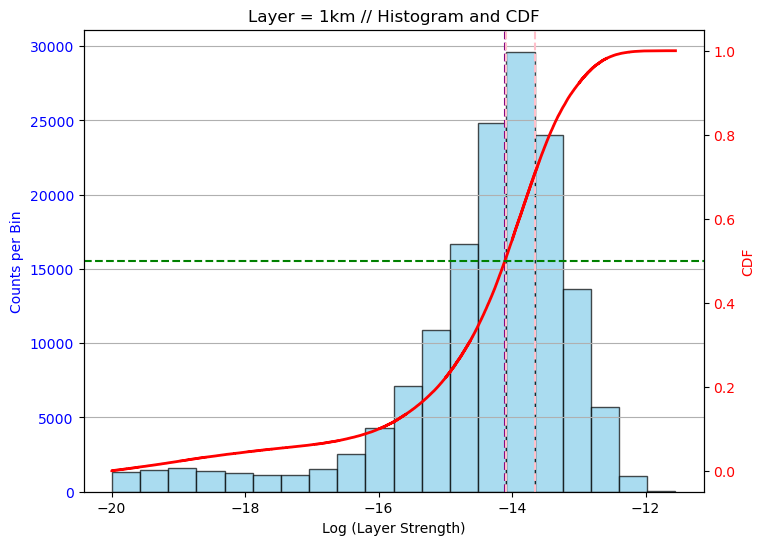

Max Value =  -11.55
Min Value =  -20.0
Median Value =  -14.11
Standard Deviation =  1.39
Average =  -14.42
Mode Bin Value =  -13.87 +/- 0.21


In [30]:
layer_plot(one)

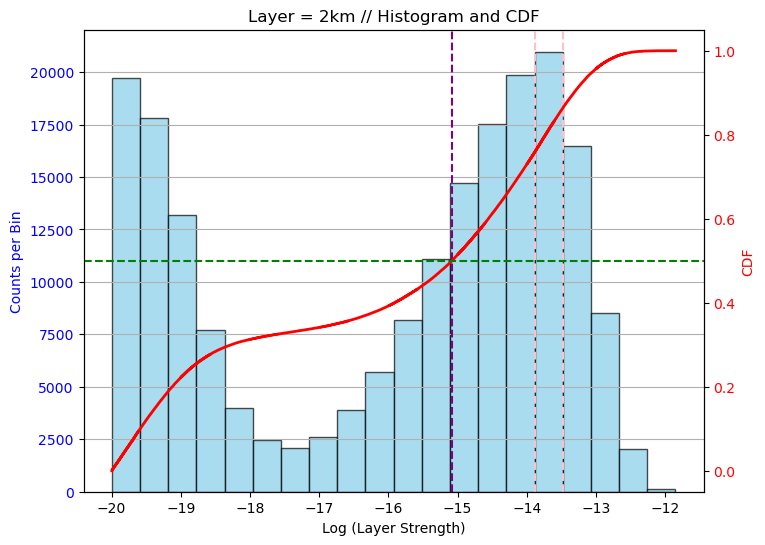

Max Value =  -11.85
Min Value =  -20.0
Median Value =  -15.08
Standard Deviation =  2.43
Average =  -15.99
Mode Bin Value =  -13.68 +/- 0.2


In [31]:
layer_plot(two)

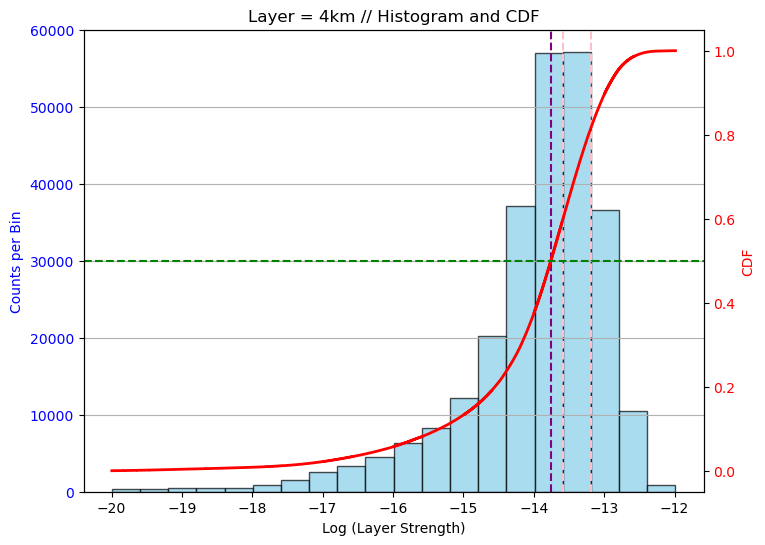

Max Value =  -11.99
Min Value =  -20.0
Median Value =  -13.76
Standard Deviation =  1.05
Average =  -13.99
Mode Bin Value =  -13.39 +/- 0.2


In [32]:
layer_plot(four)

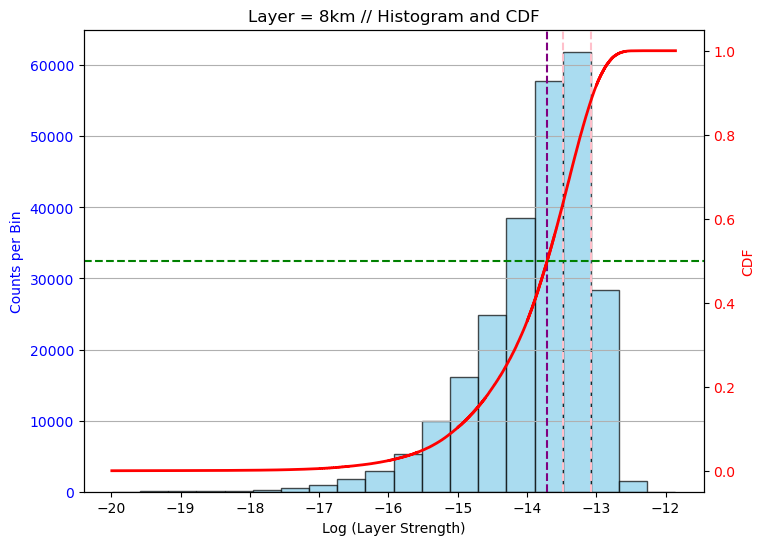

Max Value =  -11.86
Min Value =  -19.99
Median Value =  -13.71
Standard Deviation =  0.83
Average =  -13.9
Mode Bin Value =  -13.28 +/- 0.2


In [33]:
layer_plot(eight)

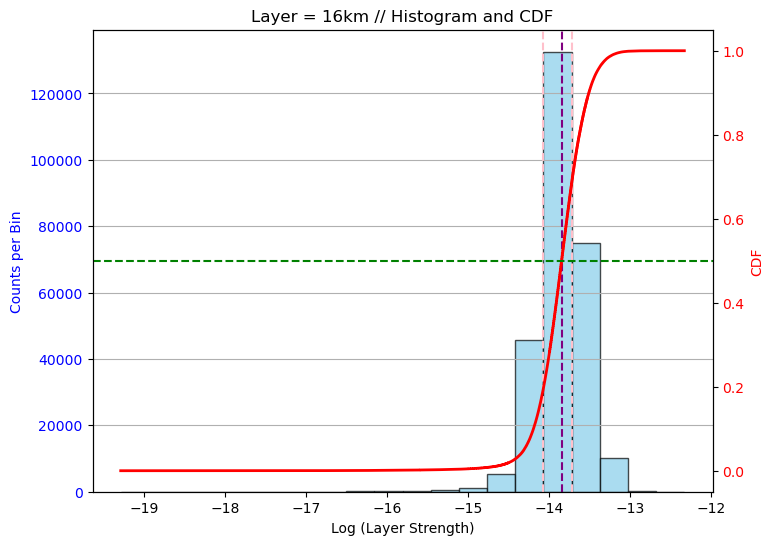

Max Value =  -12.33
Min Value =  -19.29
Median Value =  -13.85
Standard Deviation =  0.3
Average =  -13.86
Mode Bin Value =  -13.9 +/- 0.17


In [34]:
layer_plot(sixteen)

In [4]:
total_profile = []

for i in ground_layer:
    r0 = (206265 / i) * .5e-6
    profile = ( r0**(-5./3) / 0.423 ) / ( ( 2 * np.pi / .5e-6)**2 )
    total_profile.append(profile)
print(total_profile[0])
print(half[0])

1.2024992940589733e-13
-21.80966830182971


Mode Bin Value =  -12.69 +/- 0.09


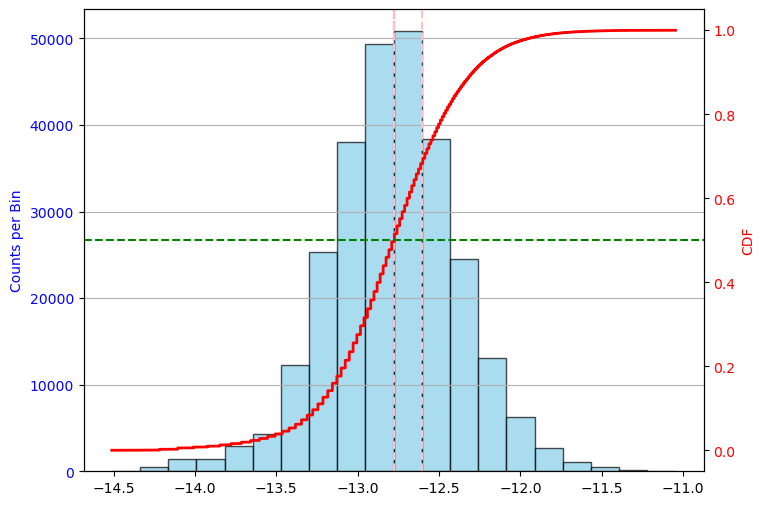

In [64]:
# --- Create figure with dual y-axis ---
fig, ax1 = plt.subplots(figsize=(8,6))

# Histogram on left y-axis
counts, bins, patches = ax1.hist(
    np.log10(total_profile), bins=20, color='skyblue', edgecolor='black', alpha=0.7, label="Histogram"
)

index_max_count = np.argmax(counts)

#ax1.set_xlabel("Log (Layer Strength)")
ax1.set_ylabel("Counts per Bin", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Add vertical line at 50% ground layer
ax1.axvline(x=np.median(np.log10(total_profile)), color="purple", linestyle="--", linewidth=1.5)

ax1.axvline(x=bins[index_max_count], color="pink", linestyle="--", linewidth=1.5)
ax1.axvline(x=bins[index_max_count+1], color="pink", linestyle="--", linewidth=1.5)

# CDF on right y-axis
ax2 = ax1.twinx()
sorted_vals = np.sort(np.log10(total_profile))
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
ax2.plot(sorted_vals, cdf, color="red", linewidth=2, label="CDF")
ax2.set_ylabel("CDF", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Add horizontal line at 50% CDF
ax2.axhline(y=0.5, color="green", linestyle="--", linewidth=1.5)
    
ax1.grid(True, axis="y")
#plt.xlim(0,1.5)

mode = ( bins[index_max_count+1] + bins[index_max_count] ) / 2
edge = bins[index_max_count+1] - mode

print('Mode Bin Value = ', round(mode,2), '+/-', round(edge,2))

#plt.savefig('wind_dir_hist.png')
plt.show()

In [11]:
print('Max Value = ', round(np.max(total_profile),2))
print('Min Value = ', round(np.min(total_profile),2))
print('Median Value = ', round(np.median(total_profile),2))
print('Standard Deviation = ', round(np.std(total_profile),2))

Max Value =  -11.05
Min Value =  -14.51
Median Value =  -12.77
Standard Deviation =  0.4
